# LSCI 220 Assignment 2
## Dominic Kelly, Id 198511370

# Introduction
This work aims to build on the processing done for Assignment 1.

In that project, I loaded bodies of text made up of album reviews from Rip It Up magazine in 1977 (the year it started publishing) and 1997.

The most interesting finding was that in 1997 there were more reviews per publication but they were shorter. And perhaps more interestingly, word frequencies suggested that certain vocabulary that is used to describe music (**arrangement**, **lyric** and **rhythm**) had been superceded by words that identify musical genres, such as **hardcore**, **metal** and **punk**.

For this assignment I wanted to use more tools to look for additional information about this trend or find out other things about the language of Rip It Up's album reviews.

I also added a third corpus - album reviews from 1997 editions of Rolling Stone magazine, accessed through the University's subscription to the Proquest service.



In [17]:
# BORROWED FROM COURSE MATERIAL!
# make a helper function to create dictionaries.

import requests
from nltk import word_tokenize

# create a function to read in resource and output a dictionary.
def get_word_rating_resource(url):
  """helper function to get lexical resources
  resources are hosted on github as .txt files in the form of Word\tValue\n
  """
  # read the raw text and split on newlines
  raw = requests.get(url).text.split('\n')

  # split each pair and convert value to rounded float
  # the if statement is there to avoid indexing errors when a row in a resource doesn't have complete data
  raw_list = [(pair.split('\t')[0], round(float(pair.split('\t')[1]), 3)) for pair in raw if len(pair.split('\t')) == 2]

  # create a dictionary and return it
  return dict(raw_list)

def calculate_metric(text, dictionary):
  # create empty output container
  metric = []

  # tokenize the text (and any other preprocessing you might need)
  tokens = word_tokenize(text)

  # check if token is in dictionary and append to metric output if so
  for token in tokens:
    if token in dictionary.keys():
      metric.append(dictionary[token])
  return metric

def calculate_metric_tokenised(tokens, dictionary):
  # create empty output container
  metric = []

  # check if token is in dictionary and append to metric output if so
  for token in tokens:
    if token in dictionary.keys():
      metric.append(dictionary[token])

  misses = [token for token in tokens if token not in dictionary.keys()]
  return metric, misses

In [18]:
from ast import pattern
import nltk
import string
from nltk import FreqDist
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

from enum import Enum

class CorpusIDs(Enum):
    RIU_1977 = 0
    RIU_1997 = 1
    RS_1997 = 2

punctuation_set = set(string.punctuation)

# additional punctuation are pieces of text that I found were appearing in the results 
# that I would like to have been removed with other punctuation
additional_punctuation = set(["'s", "'m", "'", '.', '"', "n't","'ve",
                              '’', '“', '”', '’;', '’’', '.)', '("',
                              '–', '—', '...', '``', "''", '‘', ',"',
                              '•', '”.', '",', '”,', '.):', '":', '’)',
                              '.”', ".'", '’,','’),', '–,', '—,', '’.', 
                              '(‘', '".', ').', '."', "')", '!!',
                              '")', '"),', '").', '";', '.’',
                              "',", '’).', "-'", '--', '?"'])

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nltk.download('wordnet')
nltk.download('omw-1.4') 

lemmatizer = WordNetLemmatizer()
corpus_root = '.'  # Directory containing text files
file_pattern = r'.*\.txt'  # Pattern to match .txt files
tokeniser = nltk.tokenize.WordPunctTokenizer()


# define a few functions.

def do_scrubbing(tokens: list, remove_punctuation=True, remove_additional_puctuation=True, remove_stopwords=True, lowercase=True, lemmatize=True) -> list:
    # Most of the cleaning out of punctuation, stopwords, plural forms etc, all in one place.
    # print("Initial token count:", len(tokens))
    if lowercase:
        tokens = [token.lower() for token in tokens]
    if (remove_punctuation):
        tokens = [word for word in tokens if word not in punctuation_set]
        # tokens = [token.translate(str.maketrans('', '', string.punctuation)) for token in tokens]

    if remove_additional_puctuation:
        tokens = [word for word in tokens if word not in additional_punctuation]

    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]

    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # print("Final token count after scrubbing:", len(tokens))
    return tokens

# for analysing the text of the reviews, I prefer to exclude the headers that contain album and artist names, record labels and reviewer names
def remove_header_lines(body: str, pattern: str) -> str:
    lines = body.split('\n')
    reg_exp = re.compile(pattern)
    cleaned_lines = [line for line in lines if not reg_exp.search(line)]
    return '\n'.join(cleaned_lines)

def draw_wordcloud(frequencies: FreqDist, title: str):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(frequencies.most_common(20)))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off") # Turn off the axis labels
    plt.title(title)
    plt.show()

def normalise_frequencies(frequencies: FreqDist, token_count: int) -> FreqDist:
    normalized_frequencies = FreqDist()
    for word, freq in frequencies.items():
        norm_freq = freq / token_count * 100
        normalized_frequencies[word] = norm_freq
    return normalized_frequencies

import os
import re
from collections import Counter
import numpy as np

# Path to your folder containing Hansard .txt files
folder_path = 'hansard'

def get_hansard_frequencies(folder):
    word_counts = Counter()
    total_words = 0

    for filename in os.listdir(folder):
        if filename.endswith('.txt'):
            with open(os.path.join(folder, filename), 'r', encoding='utf-8') as f:
                # Basic cleaning: lowercase and keep only alphanumeric characters
                text = f.read().lower()
                words = re.findall(r'\b\w+\b', text)
            
                word_counts.update(words)
                total_words += len(words)

    # Convert to DataFrame
    df = pd.DataFrame(word_counts.items(), columns=['word', 'raw_count'])

    # Normalize to Frequency Per Million Words (FPMW)
    df['fpmw'] = (df['raw_count'] / total_words) * 1000000

    # Apply Log10 transformation
    df['log10_fpmw'] = np.log10(df['fpmw'] + 1)

    return df, total_words

def get_hansard_dict()->dict:
    word_counts = Counter()
    total_words = 0
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            with open(os.path.join(folder_path, filename), 'r', encoding='utf-8') as f:
                # Basic cleaning: lowercase and keep only alphanumeric characters
                text = f.read().lower()
                words = re.findall(r'\b\w+\b', text)
                
                word_counts.update(words)
                total_words += len(words)
    
    # Convert to DataFrame
    df = pd.DataFrame(word_counts.items(), columns=['word', 'raw_count'])
    
    # Normalize to Frequency Per Million Words (FPMW)
    df['fpmw'] = (df['raw_count'] / total_words) * 1000000
    
    # Apply Log10 transformation
    df['log10_fpmw'] = np.log10(df['fpmw'] + 1)
    
    # return df, total_words

    hansard_df, grand_total = get_hansard_frequencies(folder_path)
    hansard_dict = dict(zip(hansard_df['word'], hansard_df['log10_fpmw']))
    return hansard_dict

import kagglehub
from borrowed_functions import get_word_rating_resource

# Download latest version
path = kagglehub.dataset_download("rtatman/english-word-frequency")


def get_SUBTLEXUS_dict()->dict:
    SUBTLEXUS_url = 'https://raw.githubusercontent.com/scskalicky/LING-226-vuw/main/lexical-resources/subtlxus_frequency.txt'
    SUBTLEXUS_dict = get_word_rating_resource(SUBTLEXUS_url)
    return SUBTLEXUS_dict

import pandas as pd
import numpy as np

def get_google_dict()->dict:
    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("rtatman/english-word-frequency")

    # Read the CSV file
    df = pd.read_csv(f"{path}/unigram_freq.csv")

    total_count = df['count'].sum()
    TOTAL_GOOGLE_CORPUS_WORDS = 100000000000

    df['fpmw'] = df['count'] / TOTAL_GOOGLE_CORPUS_WORDS * 1000000
    df['log10_fpmw'] = round(np.log10(df['fpmw'] + 1), 3)

    # put word and log10_frequency into a dictionary
    google_dict = dict(zip(df['word'], df['log10_fpmw']))
    return google_dict



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [19]:
missing_adjectives = {
    'famous': 4,
    'forgettable': -4,
    'uninspired': -4,
    'monotonous': -4,
    'exemplary': 4,
    'legendary': 4,
    'exceptional': 4,
    'incredible': 4,
    'sumptuous': 4,
    'seminal': 4,
    'unlistenable': -4,
    'tremendous': 4,
    'memorable': 3,
    'evocative': 3,
    'infectious': 3,
    'predictable': -3,
    'inventive': 3,
    'dramatic': 3,
    'derivative': -3,
    'essential': 3,
    'incendiary': 3,
    'monstrous': -3,
    'mellifluous': 3,
    'pretentious': -3,
    'ponderous': -3,
    'extraordinary': 3,
    'unimaginative': -3,
    'fatuous': -3,
    'mawkish': -3,
    'classic': 2,
    'considerable': 2,
    'atmospheric': 2,
    'notable': 2,
    'exotic': 2,
    'soulful': 2,
    'wanna-be': -2,
    'pedestrian': -2,
    'sloppy': -2,
    'ingenious': 2,
    'well-crafted': 2,
    'commercial': -1,
    'lyrical': 1,
    'major': 1,
    'spiritual': 1,
    'stylistic': 1,
    'corporate': -1,
    'danceable': 1,
    'radical': 1,
    'golden': 1,
    'definitive': 1,
    'understated': 1,
    'ordinary': -1,
    'unable': -1,
    'poppy': 1,
    'physical': 1,
    'cinematic': 1,
    'crucial': 1,
    'sing-along': 1,
    'raucous': 1,
    'anthemic': 1,
    'poetic': 1,
    'multi-layered': 1,
    'listenable': 1,
    'well-worn': -1,
    'acoustic': 0.5,
    'hot': 0.5,
    'orchestral': 0.5,
    'simplistic': -0.5,
    'self-conscious': -0.5,
    'emotive': 0.5,
    'able': 0.2,
    'contemporary': 0.2,
    'usual': -0.1,
    'modern': -0.1,
    'average': -0.1,
    'similar': -0.1,
    'consistent': 0.1,
    'laconic': 0.1,
}

updates_to_vader_values = {
    'melancholy': 2,
}

other_missing_words = {
    'fantastically': 1,
}

In [ ]:
from nltk.corpus import PlaintextCorpusReader

# now the actual work

this_corpus = PlaintextCorpusReader(corpus_root, file_pattern)

raw_review_corpus = [None, None, None]
review_corpus = [None, None, None]
review_tokens = [None, None, None]
scrubbed_tokens = [None, None, None]
frequencies = [None, None, None]
normalised_frequencies = [None, None, None]


# Access the text

raw_review_corpus[CorpusIDs.RIU_1977.value] = this_corpus.raw(['RECORDS 77.06.01.txt', 'RECORDS 77.07.01.txt', 'RECORDS 77.08.01.txt', 'RECORDS 77.09.01.txt', 'RECORDS 77.10.01.txt', 'RECORDS 77.11.01.txt', 'RECORDS 77.12.01.txt'])
raw_review_corpus[CorpusIDs.RIU_1997.value] = this_corpus.raw(['ALBUMS 97.06.01.txt', 'ALBUMS 97.07.01.txt', 'ALBUMS 97.08.01.txt', 'ALBUMS 97.09.01.txt', 'ALBUMS 97.10.01.txt', 'ALBUMS 97.11.01.txt', 'ALBUMS 97.12.01.txt'])
raw_review_corpus[CorpusIDs.RS_1997.value] = this_corpus.raw(['RS97.07.10.txt', 'RS97.08.07.txt', 'RS97.08.21.txt', 'RS97.09.04.txt', 'RS97.09.18.txt', 'RS97.10.02.txt', 'RS97.10.16.txt'])

for year in [CorpusIDs.RIU_1977.value, CorpusIDs.RIU_1997.value, CorpusIDs.RS_1997.value]:
    review_corpus[year] = remove_header_lines(raw_review_corpus[year], r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')
    review_tokens[year] = tokeniser.tokenize(review_corpus[year])
    scrubbed_tokens[year] = do_scrubbing(review_tokens[year])
    

Before looking at frequencies, a few simple metrics:

In [21]:
from nltk.text import Text
import pandas as pd
raw_review_tokens = [None, None, None]
headings = ['Year', 'Token Count', 'Review Count', 'Paragraph Count', 'Paragraphs per Review', 'Tokens per Review', 'TTR']
data = []
for year in [CorpusIDs.RIU_1977.value, CorpusIDs.RIU_1997.value, CorpusIDs.RS_1997.value]:
    token_type_count = len(set(scrubbed_tokens[year]))
    token_count = len(scrubbed_tokens[year])
    TTR = token_type_count / token_count
    paragraphs = review_corpus[year].split('\n')
    num_paragraphs = len(paragraphs)
    tokens_per_paragraph = token_count / num_paragraphs
    raw_review_tokens[year] = tokeniser.tokenize(raw_review_corpus[year])
    num_non_reviews = review_tokens[year].count('reviewed')
    num_reviews = raw_review_tokens[year].count('Reviewed') - num_non_reviews
    paragraphs_per_review = num_paragraphs / num_reviews
    tokens_per_review = token_count / num_reviews
    data.append([CorpusIDs(year).name, token_count, num_reviews, num_paragraphs, paragraphs_per_review, tokens_per_review, TTR])

df = pd.DataFrame(data, columns=headings )
df['TTR'] = df['TTR'].round(3)
df['Paragraphs per Review'] = df['Paragraphs per Review'].round(2)
df['Tokens per Review'] = df['Tokens per Review'].round(2)
display(df)


,Year,Token Count,Review Count,Paragraph Count,Paragraphs per Review,Tokens per Review,TTR
0,RIU_1977,17578,83,592,7.13,211.78,0.297
1,RIU_1997,25736,233,511,2.19,110.45,0.300
2,RS_1997,18784,105,319,3.04,178.90,0.366


#### The tests carried out above are repeated from Assignment 1, but with the addition of the third Corpus (Rolling Stone magazine reviews).

#### New and different analysis starts here.

First of all, I extract the most common bigrams from each corpus.

In [22]:
from nltk import FreqDist, bigrams
from IPython.display import display, Markdown

from corpus_functions import CorpusIDs
for year in [CorpusIDs.RIU_1977.value, CorpusIDs.RIU_1997.value, CorpusIDs.RS_1997.value]:
    bigrams_list = list(bigrams(scrubbed_tokens[year]))
    bigrams_fdist = FreqDist(bigrams_list)
    display(Markdown(f"Most common bigrams for year {CorpusIDs(year).name}:"))
    df = pd.DataFrame(bigrams_fdist.most_common(10), columns=['Word', 'Frequency'])
    display(df)
    # for freq in bigrams_fdist.most_common(10):
    #     print(freq)


Most common bigrams for year RIU_1977:

,Word,Frequency
0,"(rock, n)",25
1,"(n, roll)",24
2,"(rhythm, section)",13
3,"(first, album)",13
4,"(song, like)",12
5,"(sound, like)",12
6,"(side, one)",10
7,"(live, album)",10
8,"(rock, roll)",10
9,"(new, album)",9


Most common bigrams for year RIU_1997:

,Word,Frequency
0,"(n, roll)",30
1,"(rock, n)",28
2,"(sound, like)",24
3,"(hip, hop)",21
4,"(record, company)",17
5,"(punk, rock)",13
6,"(drum, n)",12
7,"(n, bass)",12
8,"(r, b)",12
9,"(liner, note)",11


Most common bigrams for year RS_1997:

,Word,Frequency
0,"(hip, hop)",24
1,"(sound, like)",16
2,"(r, b)",14
3,"(dance, floor)",11
4,"(bob, dylan)",9
5,"(black, ark)",9
6,"(song, like)",9
7,"(solo, album)",9
8,"(new, album)",8
9,"(title, track)",8


As with single tokens, the most frequent bigrams from the two Rip It Up corpora suggest a shift from musical vocabulary to genre or "music business" vocabulary.

The Rolling Stone results are little different, with Bob Dylan and one of his album names standing out. Why the New Zealand magazine consistently talks about Rock 'n Roll, while Rolling Stone doesn't seem to at all is a mystery that might be worth looking into.

How about trigrams?

In [23]:
from nltk import FreqDist, trigrams
for year in [CorpusIDs.RIU_1977.value, CorpusIDs.RIU_1997.value, CorpusIDs.RS_1997.value]:
    trigrams_list = list(trigrams(scrubbed_tokens[year]))
    trigrams_fdist = FreqDist(trigrams_list)
    display(Markdown(f"Most common trigrams for year {CorpusIDs(year).name}:"))
    df = pd.DataFrame(trigrams_fdist.most_common(10), columns=['Word', 'Frequency'])
    display(df)    
    # for freq in trigrams_fdist.most_common(10):
    #     print(freq)

Most common trigrams for year RIU_1977:

,Word,Frequency
0,"(rock, n, roll)",24
1,"(average, white, band)",5
2,"(rhythm, n, blue)",4
3,"(day, dog, race)",3
4,"(time, love, hero)",3
5,"(miracle, billy, paul)",3
6,"(allman, brother, band)",3
7,"(ben, e, king)",3
8,"(walk, wild, side)",3
9,"(rock, roll, heart)",3


Most common trigrams for year RIU_1997:

,Word,Frequency
0,"(rock, n, roll)",28
1,"(drum, n, bass)",12
2,"(dark, dear, heart)",5
3,"(jonathan, fire, eater)",4
4,"(ten, foot, pole)",3
5,"(blue, sky, mar)",3
6,"(voodoo, glow, skull)",3
7,"(ocean, colour, scene)",3
8,"(simon, le, bon)",3
9,"(yeah, yeah, yeah)",3


Most common trigrams for year RS_1997:

,Word,Frequency
0,"(wu, tang, clan)",6
1,"(notorious, b, g)",4
2,"(anthology, american, folk)",4
3,"(american, folk, music)",4
4,"(20, year, ago)",3
5,"(nine, inch, nail)",3
6,"(great, big, world)",3
7,"(straight, till, morning)",3
8,"(blood, dance, floor)",3
9,"(supa, dupa, fly)",3


Trigrams are a little murkier with band names appearing frequently in all three top tens. Fortunately "average white band" is a band name and not a slur. 

Next, I created average frequencies for all three corpora. I wanted to see if the choice of dictionary whose frequencies were being compared to made a difference. So the code loads SUBTLEus, the dictionary created by google from their billion word corpus, and one that is created within this project, based on text from Hansard captured in 1977.

In [ ]:
import pandas as pd

hansard_dict = get_hansard_dict()
google_dict = get_google_dict()
SUBTLEXUS_dict = get_SUBTLEXUS_dict()
data_rows = []

for year in [CorpusIDs.RIU_1977.value, CorpusIDs.RIU_1997.value, CorpusIDs.RS_1997.value]:
    metric1, misses = calculate_metric_tokenised(scrubbed_tokens[year], google_dict)
    metric2, misses = calculate_metric_tokenised(scrubbed_tokens[year], SUBTLEXUS_dict)
    metric3, misses = calculate_metric_tokenised(scrubbed_tokens[year], hansard_dict)
    data_rows.append([CorpusIDs(year).name, f"{sum(metric1)/len(metric1):.2f}", f"{len(metric1)/len(scrubbed_tokens[year])*100:.2f}", 
                     f"{sum(metric2)/len(metric2):.2f}", f"{len(metric2)/len(scrubbed_tokens[year])*100:.2f}",
                     f"{sum(metric3)/len(metric3):.2f}", f"{len(metric3)/len(scrubbed_tokens[year])*100:.2f}"])

headings = ['Year', 'Google Avg \nLog10 Freq', 'Google \nCoverage %',
            'SUBTLEXUS Avg \nLog10 Freq', 'SUBTLEXUS \nCoverage %',
            'Hansard Avg \nLog10 Freq', 'Hansard \nCoverage %']
df_metrics = pd.DataFrame(data_rows, columns=headings)
display(df_metrics)

,Year,Google Avg \nLog10 Freq,Google \nCoverage %,SUBTLEXUS Avg \nLog10 Freq,SUBTLEXUS \nCoverage %,Hansard Avg \nLog10 Freq,Hansard \nCoverage %
0,RIU_1977,2.46,98.03,3.32,83.80,1.57,87.11
1,RIU_1997,2.38,96.76,3.21,83.77,1.47,84.63
2,RS_1997,2.22,96.55,3.04,80.34,1.34,78.79


The scores are all similar and follow the same pattern regardless of the dictionary used.

They are relatively low, and so suggest high use of uncommon words. Since we're talking about nusic criticism, a little uncommonness is probably understandable.

If we take the use of less common words to be a sign of "sophistication", then we seem to be seeing an increase in sophistication from RIU in 1977 to 1997, with Rolling Stone fractionally ahead of both.

In interesting but unsurprising results, the massive google corpus has the best coverage. But the dictionary created from 1977 Hansard has quite high coverage of the RIU 1977 corpus, and that falls away for the others.

Next: Concreteness.

In [ ]:
concrete_url = 'https://raw.githubusercontent.com/scskalicky/LING-226-vuw/main/lexical-resources/concreteness.txt'

data = []

concrete_dict = get_word_rating_resource(concrete_url)
for year in [CorpusIDs.RIU_1977.value, CorpusIDs.RIU_1997.value, CorpusIDs.RS_1997.value]:
    metric, misses = calculate_metric_tokenised(scrubbed_tokens[year], concrete_dict)
    data.append([CorpusIDs(year).name, f"{sum(metric)/len(metric):.2f}", f"{len(metric)/len(scrubbed_tokens[year])*100:.2f}"])
headings = ['Year', 'Avg Concreteness', 'Coverage %']
df_concreteness = pd.DataFrame(data, columns=headings)
display(df_concreteness)

,Year,Avg Concreteness,Coverage %
0,RIU_1977,3.12,82.32
1,RIU_1997,3.14,81.27
2,RS_1997,3.19,78.77


This time there appears to be less abstractness and more concreteness in the Rolling Stone corpus over either RIU one, and with more concreteness in the 1997 over the 1977.

The scores for coverage create plenty of room for doubt about the accuracy and relevance of the concreteness results.

There are hints in these results of slight qualitative differences among the corpora. But the differences in scores among the corpora for each test are slight and the coverage low enough to suggest that they aren't really revealing much.

I had higher hopes for the sentiment tests. Algorithmically anlysing text for sentiment should be work well with criticism. Or so I thought.

My description of the goal of the next block of code has been moved to the critical reflection.

What this code leaves out is some work I did that extracted words from the corpora that were missing from vader's lexicon. And for those missing words I got it to print out those that nltk considers _adjectives_. I then looked through the 300 or so most frequently used from that list and gave scores to a few that I judged deserve them in this context. The result is in a file called `music_criticism_lexicon.py`. I also added a couple of other words that I came across in reviews that I thought deserved to be there or that had VADER scores that I thought were just wrong.

So as part of the sentiment analysis below, the code explicitly modifies some of the vader scores for particular words.

First, here are some functions that get used further on.

In [26]:
class CriticSentiment:
    def __init__(self, name: str):
        self.name = name
        self.sentences = []
        self.sentiment_scores = []
        self.absolute_average = 0.0
        self.variance = 0.0
        self.mean = 0.0

    def calculate_statistics(self):
        if len(self.sentiment_scores) == 0:
            self.absolute_average = 0.0
            self.mean = 0.0
            self.variance = 0.0
            return
        self.absolute_average = sum(abs(s) for s in self.sentiment_scores) / len(self.sentiment_scores)
        self.mean = sum(s for s in self.sentiment_scores) / len(self.sentiment_scores)
        self.variance = sum((s - self.mean) ** 2 for s in self.sentiment_scores) / len(self.sentiment_scores)

In [ ]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

def missing_from_vader(corpus: str) -> set:
    """returns a set of words that are in the corpus but not in the VADER lexicon"""
    vader_lexicon = set(sid.lexicon.keys())
    tokens = nltk.word_tokenize(corpus)
    corpus_words = set(tokens)
    missing_words = corpus_words - vader_lexicon
    return missing_words
  
def get_vader_sentiment(sentence):
    """uses VADER to get sentiment for a given sentence"""
    scores = sid.polarity_scores(sentence)
    return scores['compound']

def add_music_criticism_lexicon():
    """adds the music criticism lexicon to the VADER lexicon"""
    sid.lexicon.update(missing_adjectives)
    sid.lexicon.update(other_missing_words)
    sid.lexicon.update(updates_to_vader_values)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [28]:
def plot_sentiment_violins(sentiment_dict):
    import matplotlib.pyplot as plt
    
    names = [c.name for c in sentiment_dict.values()]
    scores = [c.sentiment_scores for c in sentiment_dict.values()]
    
    plt.figure(figsize=(12, 6))
    parts = plt.violinplot(scores, positions=range(len(names)), showmeans=True, showmedians=True)
    plt.xticks(range(len(names)), names, rotation=45, ha='right')
    plt.ylabel('Sentiment Score')
    plt.title('Sentiment Distribution (Violin Plot)')
    plt.tight_layout()
    plt.show()



def plot_sentiment_violins_grid(sentiment_dict, n_rows=3, n_cols=3, min_sentences=30):
    import matplotlib.pyplot as plt
    
    # Filter critics by minimum sentence count
    critics = [c for c in sentiment_dict.values() if len(c.sentiment_scores) >= min_sentences]
    plots_per_page = n_rows * n_cols
    
    # Scale figure size inversely with number of plots
    base_width = min(4, 20 / n_cols)
    base_height = min(3.5, 18 / n_rows)
    
    for page in range(0, len(critics), plots_per_page):
        batch = critics[page:page + plots_per_page]
        n_plots = len(batch)
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_width*n_cols, base_height*n_rows))
        axes = axes.flatten() if n_plots > 1 else [axes]
        
        for idx, critic in enumerate(batch):
            parts = axes[idx].violinplot([critic.sentiment_scores], positions=[0], 
                                          showmeans=True, showmedians=True)
            axes[idx].set_title(f'{critic.name}', fontsize=8)
            axes[idx].set_ylabel('Sentiment Score', fontsize=7)
            axes[idx].tick_params(labelsize=6)
            axes[idx].set_xticks([])
        
        # Hide empty subplots
        for idx in range(n_plots, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=2.0)
        page_num = page // plots_per_page + 1
        total_pages = (len(critics) + plots_per_page - 1) // plots_per_page
        plt.suptitle(f'Page {page_num} of {total_pages}', y=0.998, fontsize=10)
        plt.show()

def plot_sentiment_violins_tabbed(sentiment_dict, n_rows=3, n_cols=3, min_sentences=0):
    """
    Interactive tabbed version for Jupyter notebooks.
    Requires: pip install ipywidgets
    """
    try:
        import matplotlib.pyplot as plt
        from ipywidgets import widgets, interact, Output
        from IPython.display import display, clear_output
    except ImportError:
        print("This function requires ipywidgets. Install with: pip install ipywidgets")
        print("Falling back to multi-page version...")
        plot_sentiment_violins_grid(sentiment_dict, n_rows, n_cols, min_sentences)
        return
    
    # Filter critics by minimum sentence count
    critics = [c for c in sentiment_dict.values() if len(c.sentiment_scores) >= min_sentences]
    plots_per_page = n_rows * n_cols
    total_pages = (len(critics) + plots_per_page - 1) // plots_per_page
    
    # Scale figure size inversely with number of plots
    base_width = min(4, 20 / n_cols)
    base_height = min(3.5, 18 / n_rows)
    
    def show_page(page):
        start_idx = page * plots_per_page
        batch = critics[start_idx:start_idx + plots_per_page]
        n_plots = len(batch)
        
        plt.close('all')  # Close previous figures
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(base_width*n_cols, base_height*n_rows))
        axes = axes.flatten() if n_plots > 1 else [axes]
        
        for idx, critic in enumerate(batch):
            parts = axes[idx].violinplot([critic.sentiment_scores], positions=[0], 
                                          showmeans=True, showmedians=True)
            axes[idx].set_title(f'{critic.name}', fontsize=8)
            axes[idx].set_ylabel('Sentiment Score', fontsize=7)
            axes[idx].tick_params(labelsize=6)
            axes[idx].set_xticks([])
        
        # Hide empty subplots
        for idx in range(n_plots, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=2.0)
        plt.suptitle(f'Page {page + 1} of {total_pages}', y=0.998, fontsize=10)
        plt.show()
    
    # Create interactive slider
    interact(show_page, page=widgets.IntSlider(
        min=0, 
        max=total_pages-1, 
        step=1, 
        value=0, 
        description='Page:',
        continuous_update=False
    ))


In [29]:
def create_or_append_to_section(sections: map, section_title: str, current_section: str):
    section_title = section_title.strip().lower()
    section = sections.get(section_title)

    if (section):
        # print("adding to existing section:", section_title)
        sections[section_title] += '\n' + current_section
    else:
        # print("creating new section:", section_title)
        sections[section_title] = current_section

def split_by_header_text(text, header_text)->map:
    """
    Splits the given text into sections based on the specified header text.
    
    Parameters:
    text (str): The input text to be split.
    header_text (str): The header text that indicates the start of a new section.
    
    Returns:
    list: A list of sections split by the header text.
    """
    sections = {}
    current_section = ""
    section_title = ""
    
    for line in text.splitlines():
        if line.startswith(header_text):
            # get the text after the header_text
            if (section_title != ""):
                create_or_append_to_section(sections, section_title, current_section)
            section_title = line.partition(header_text)[2]
            current_section = ""
        current_section += '\n' + line
    
    if current_section and section_title != "":
        create_or_append_to_section(sections, section_title, current_section)
    
    return sections

def split_corpus_by_critic(raw_review_corpus)->map:
    result = split_by_header_text(raw_review_corpus, "Reviewed By:")

    return result


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package brown to
[nltk_data]    |     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]    |   Package brown is already up-to-date!
[nltk_data]    | Downloading package chat80 to
[nltk_data]    |     C:\Us

Extreme score 0.9697 for critic bruce belsham: All credit to Eric Carmen’s ability as a blender of styles - and by all means buy the record for songs like "She Did It" and “Love Is All That Matters" - but it’s no hopeful reflection on current levels of innovation that a retrospective talent like this shines so bright
Extreme score 0.9595 for critic peter thomson:  The Allman Band, with its solid but subtly complex rhythm section, provided the ideal ambience for Betts' fresh gentle melodies and mellifluous guitar work
Extreme score 0.9505 for critic francis stark:  There are a batch of love songs that don't seem to express much more than pleasant contentment, a funk instrumental by the band, a country song by the pedal-steel player, a cover version of Happy Days are Here Again", and a couple of songs about what Grindlay knows best - being an underemployed, dissatisfied musician
Extreme score 0.9584 for critic ken williams: The best music comes from the king of the Crescent City studios,

,Critic,Mean Sentiment,Mean Absolute Sentiment,Sentiment Variance
0,mike chunn,0.1496,0.3145,0.1584
1,jeremy templer,0.2019,0.3323,0.1581
2,john malloy,0.1202,0.2921,0.1461
3,bruce belsham,0.1558,0.3241,0.1661
4,alastair dougal,0.1960,0.3697,0.1859
5,jae renaut,0.2942,0.3746,0.1233
6,murray cammick,0.1795,0.2443,0.1160
7,peter thomson,0.1967,0.3684,0.1863
8,rhondda bosworth,0.3008,0.3902,0.1302
9,alan hunter,0.2453,0.3254,0.1275


Extreme score 0.9549 for critic troy ferguson:  The band’s revolving door policy ensured a flow of ideas and perspectives; but instead of being applauded for extraordinary vision and innovation within a narrowly-confined genre, they were treated as a joke by everyone who was not either John Peel or a card-carrying metalhead
Extreme score -0.9568 for critic troy ferguson:  But unfortunately, Lux Interior and Poison Ivy may be suffering the curse of longevity, and it just doesn’t seem quite as wild anymore
Extreme score 0.9559 for critic martin bell:  But for the most part, Shaming Of The Sun is a winning cocktail of exemplary song smithery, imbued with a rare soul and passion
Sentiment results for corpus ALBUMS 97.*:


,Critic,Mean Sentiment,Mean Absolute Sentiment,Sentiment Variance
0,justin redding,0.2383,0.3048,0.1363
1,bronwyn trudgeon,0.2236,0.4159,0.2130
2,greg fleming,0.2250,0.3880,0.1895
3,dominic waghorn,0.2311,0.3655,0.1585
4,troy ferguson,0.1105,0.3656,0.2080
5,martin bell,0.2313,0.3527,0.1701
6,kirk gee,0.1437,0.3866,0.2409
7,george kay,0.2508,0.4176,0.2057
8,mac hodge,0.1467,0.3442,0.1770
9,jesse garon,0.1068,0.4125,0.2579


Extreme score 0.9534 for critic mark kemp:  Although the rap mogul is never directly mentioned in the song's lyrics - the knight of the title refers to nighttime - Coolio's message is clear: It doesn't take a rocket scientist to decipher to whom Coolio is referring in the lines "There's nothing to fear but fear itself/And if you control the fear, then the fear is wealth
Extreme score 0.9628 for critic mark kemp:  But were we satisfied with those records simply because we expect less of the Stones these days? Steel Wheels, from 1989, was at least a welcome reprieve from the group's floundering early '80s years; 1994's Voodoo Lounge was simply a "greatest hits" collection, with the actual hits replaced by new songs that tried to conjure the spirit (if not the substance) of classics like "Lady Jane
Extreme score 0.9667 for critic tom moon:  But even these bright spots are more accomplished than inspired: Happily nonsensical, they're hammering exercises that use the trio's technically flaw

,Critic,Mean Sentiment,Mean Absolute Sentiment,Sentiment Variance
0,mark kemp,0.1902,0.3636,0.1985
1,lorraine ali,0.1917,0.4058,0.2245
2,jason cohen,0.0867,0.2566,0.1146
3,david fricke,0.1137,0.3535,0.2157
4,ed morales,0.1137,0.4051,0.2279
5,barney hoskyns,0.0800,0.3692,0.2135
6,robert levine,0.3498,0.5120,0.2242
7,galtney smith,0.0596,0.2304,0.1456
8,elisabeth vincentelli,0.1718,0.3457,0.1628
9,jon wiederhorn,0.0286,0.4112,0.2442


Overall corpus sentiment statistics for corpora:


,Corpus,Mean Sentiment,Mean Absolute Sentiment,Sentiment Variance
0,CorpusIDs.RIU_1977,0.1740,0.3299,0.1664
1,CorpusIDs.RIU_1997,0.1811,0.3647,0.1887
2,CorpusIDs.RS_1997,0.1426,0.3609,0.1995


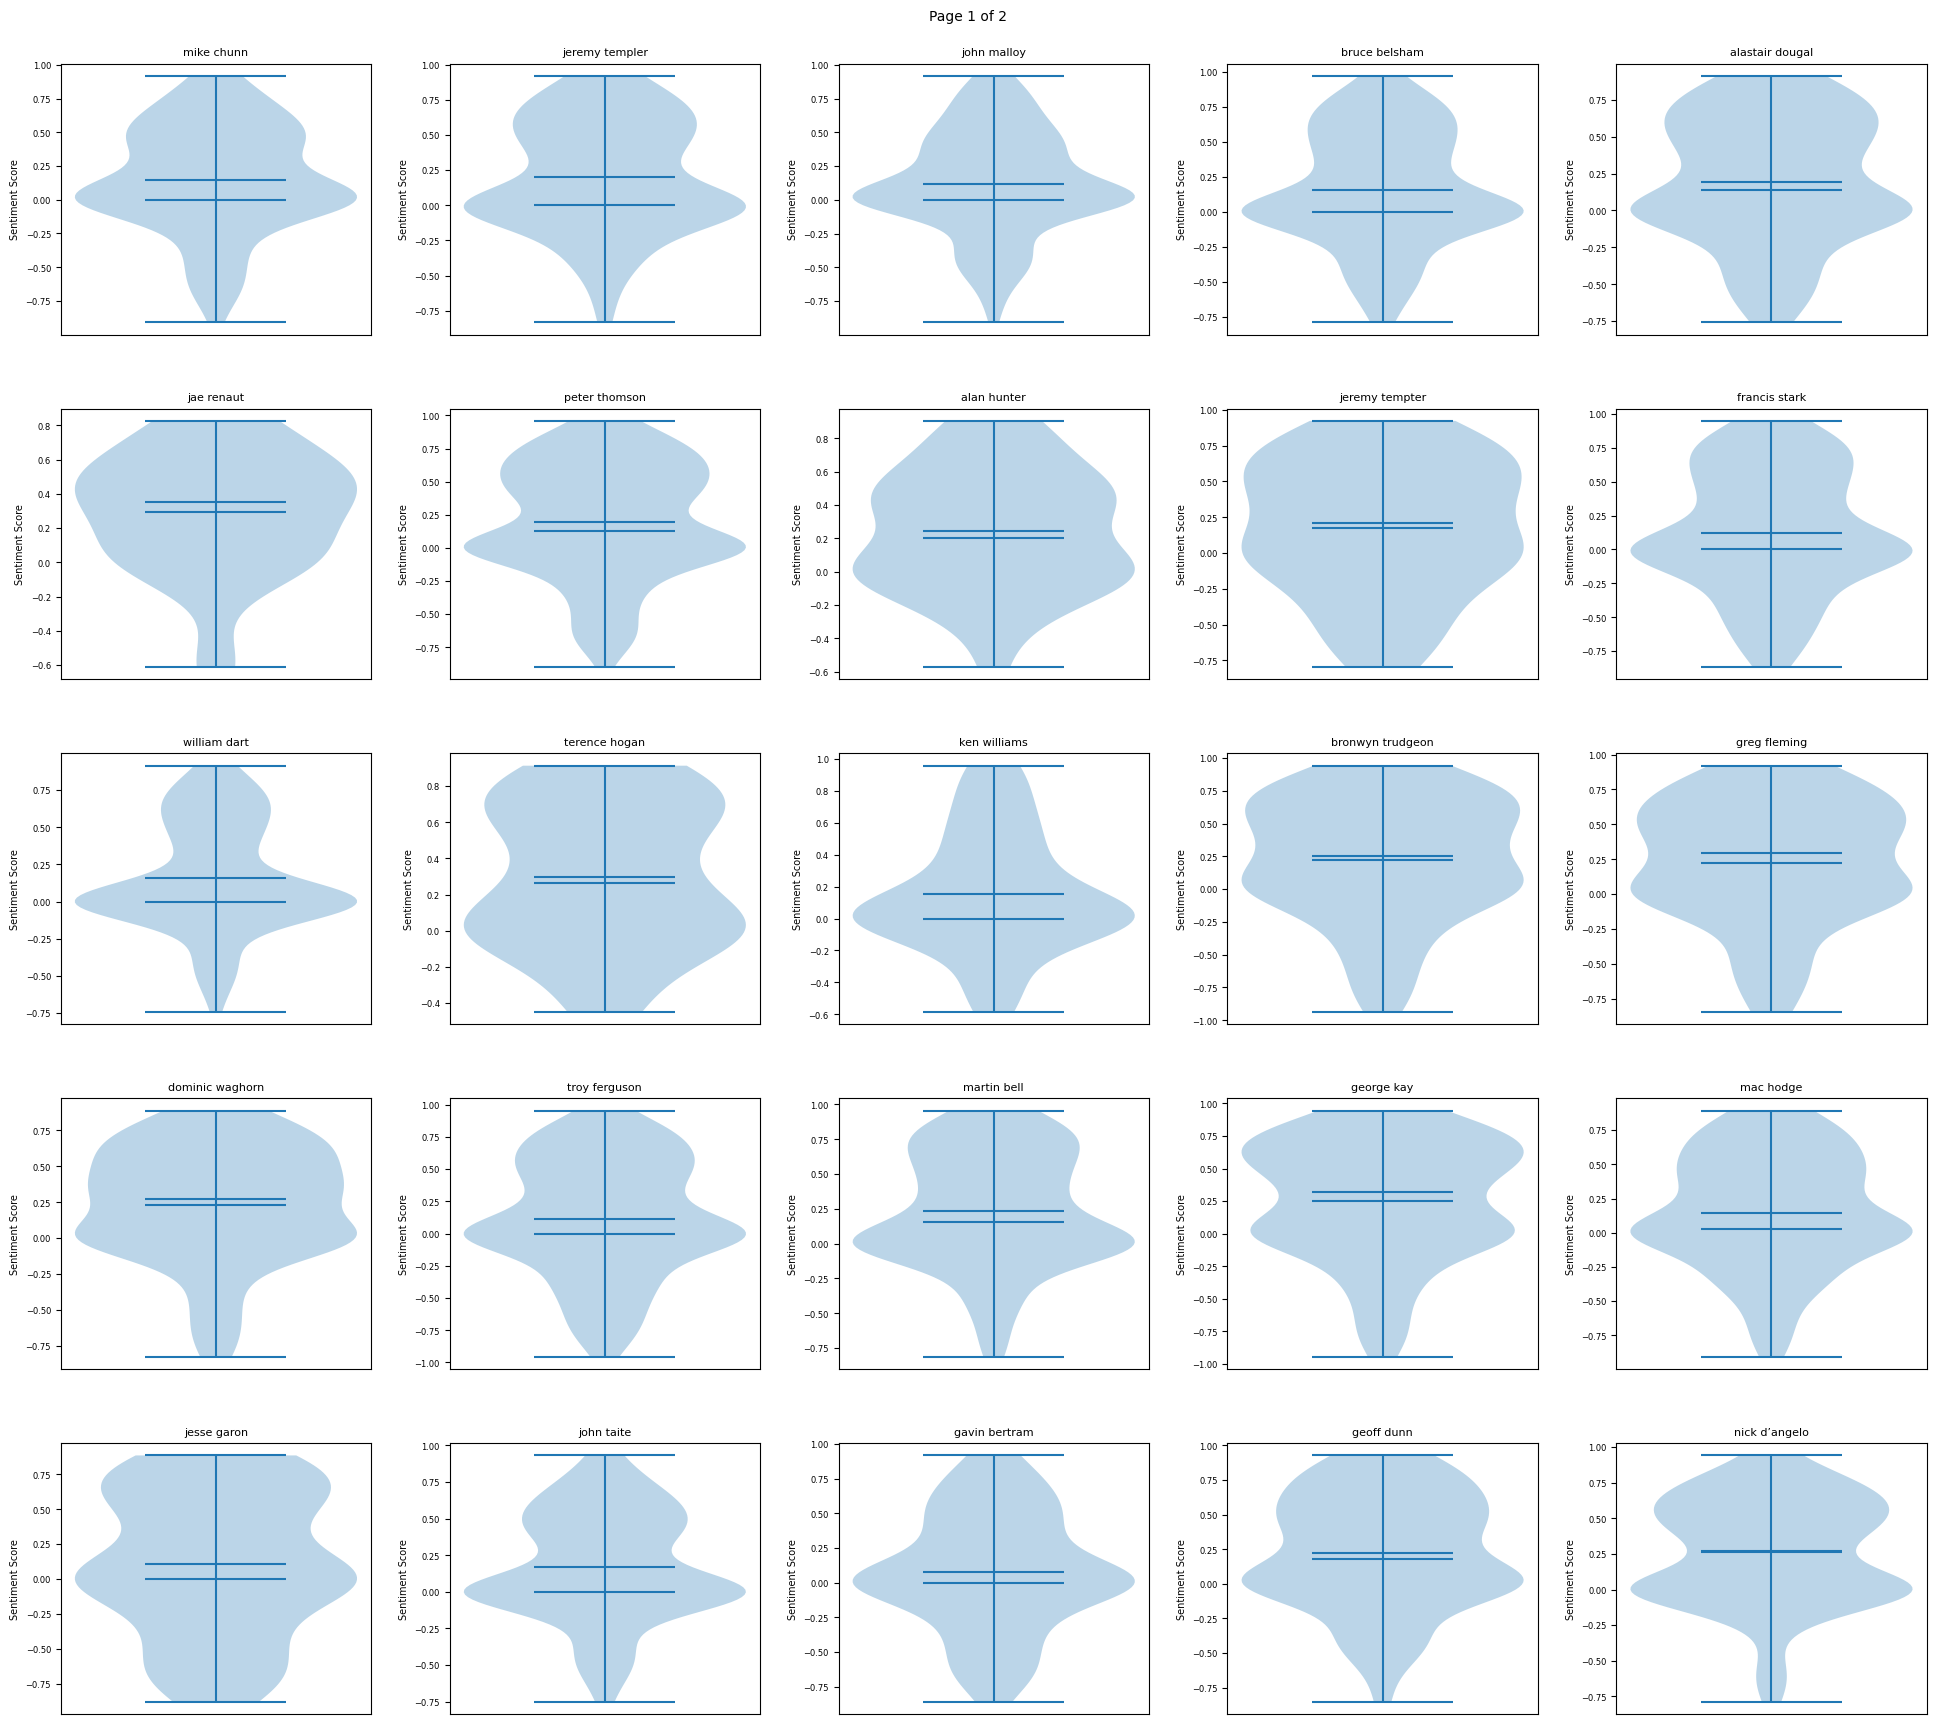

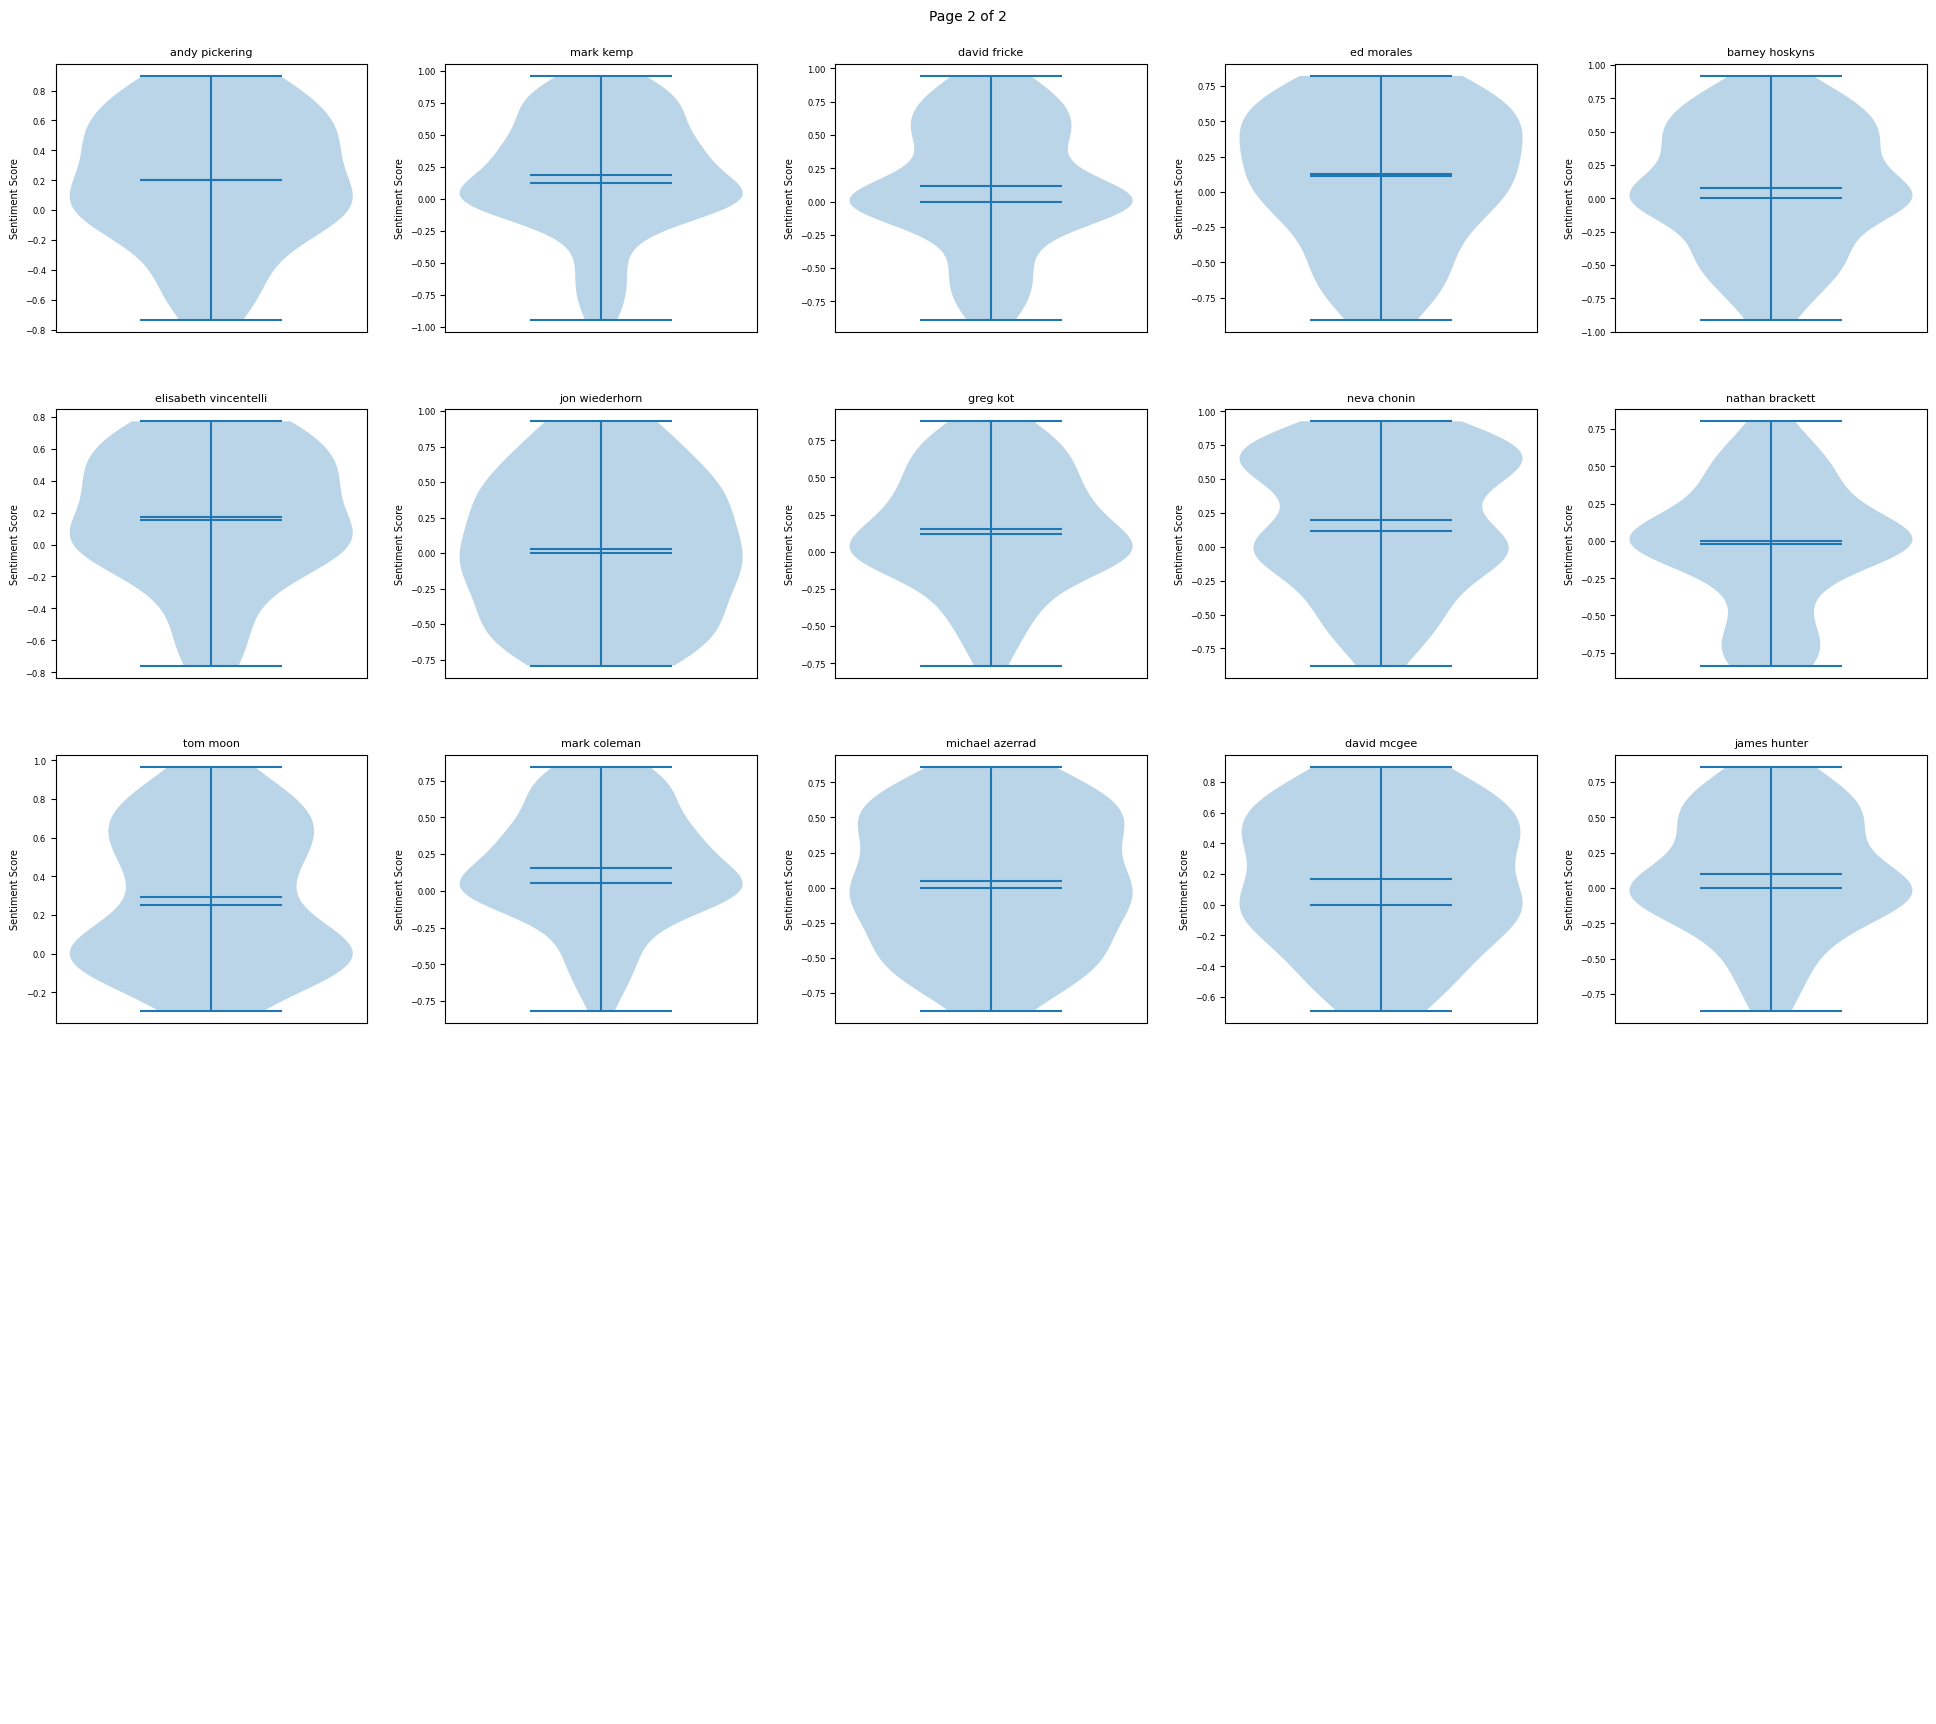

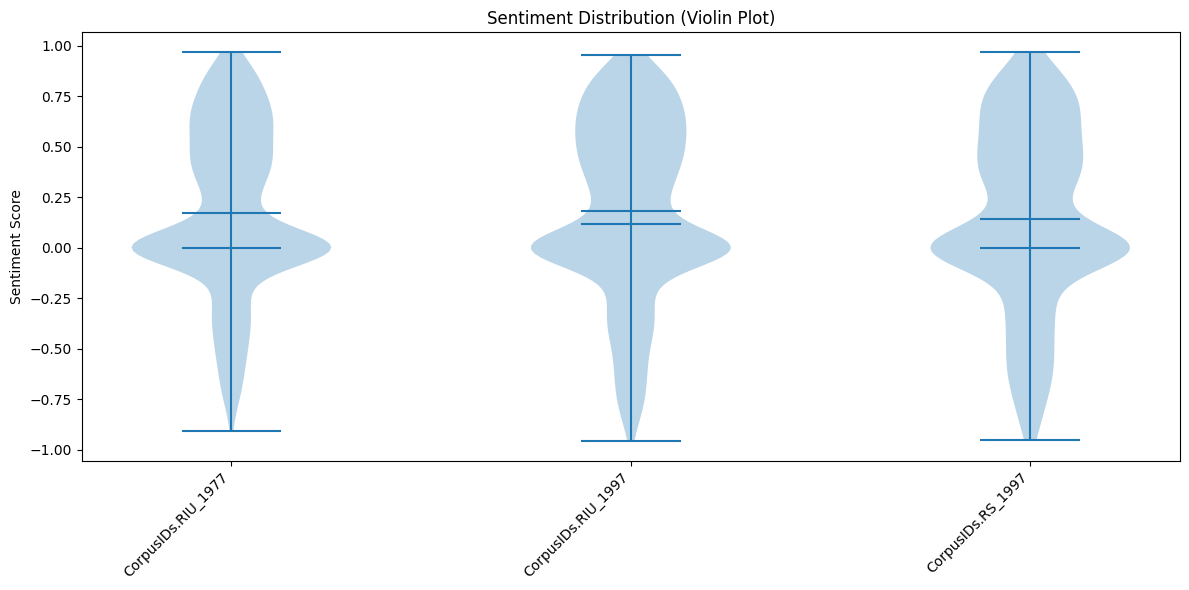

In [ ]:
import re

sentiment_by_critic = {}
corpus_sentiment = {}
# most_missing_words = {}
add_music_criticism_lexicon()
paths = ['RECORDS 77.*', 'ALBUMS 97.*', 'RS97.*']


# global most_missing_words
import nltk as nltk
nltk.download(['punkt_tab', 'averaged_perceptron_tagger_eng', 'tagsets_json', 'book'])
corpus_root = '.'  # Directory containing text files
corpus_sentiment_results = []

for CORPUS in [CorpusIDs.RIU_1977, CorpusIDs.RIU_1997, CorpusIDs.RS_1997]:
    file_pattern = paths[CORPUS.value]
    corpus = PlaintextCorpusReader(corpus_root, file_pattern)
    raw_review_corpus = corpus.raw()
    corpus_by_critic = split_corpus_by_critic(raw_review_corpus)
    tokenised_corpus_by_critic = {}
    # paragraphs_by_critic = {}
    sentences_by_critic = {}
    corpus_sentiment[CORPUS] = CriticSentiment(str(CORPUS))

    critic_sentiment_results = []

    for critic in corpus_by_critic.keys():
        corpus_by_critic[critic] = remove_header_lines(corpus_by_critic[critic], r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')
        # paragraphs_by_critic[critic] = corpus_by_critic[critic].split('\n')
        sentences_by_critic[critic] = re.split(r'[\n.]', corpus_by_critic[critic])
        sentences_by_critic[critic] = [s for s in sentences_by_critic[critic] if s.strip()]
        sentiment_by_critic[critic] = CriticSentiment(critic)
        # for para in paragraphs_by_critic[critic]:
        for sent in sentences_by_critic[critic]:
            if len(sent.strip()) == 0:
                continue
            score = get_vader_sentiment(sent.lower())
            if (abs(score) > 0.95):
                print(f"Extreme score {score} for critic {critic}: {sent}")
            sentiment_by_critic[critic].sentiment_scores.append(score)
        corpus_sentiment[CORPUS].sentiment_scores.extend(sentiment_by_critic[critic].sentiment_scores)
        sentiment_by_critic[critic].calculate_statistics()
        # print(f"Critic: {critic}, VADER mean sentiment {sentiment_by_critic[critic].mean:.4f}, mean of absolute values: {sentiment_by_critic[critic].absolute_average:.4f}, variance: {sentiment_by_critic[critic].variance:.4f}") 
        critic_sentiment_results.append([critic,
                                    f"{sentiment_by_critic[critic].mean:.4f}",
                                    f"{sentiment_by_critic[critic].absolute_average:.4f}",
                                    f"{sentiment_by_critic[critic].variance:.4f}"])
        
        tokenised_corpus_by_critic[critic] = nltk.word_tokenize(corpus_by_critic[critic])
        tokenised_corpus_by_critic[critic] = do_scrubbing(tokenised_corpus_by_critic[critic], remove_stopwords=False)

    corpus_sentiment[CORPUS].calculate_statistics()
    corpus_sentiment[CORPUS].variance = sum((s - corpus_sentiment[CORPUS].mean) ** 2 for s in corpus_sentiment[CORPUS].sentiment_scores) / len(corpus_sentiment[CORPUS].sentiment_scores) if len(corpus_sentiment[CORPUS].sentiment_scores) > 0 else 0.0
    # print(f"Corpus: {file_pattern}, VADER mean sentiment {corpus_sentiment[CORPUS].mean:.4f}, mean of absolute values: {corpus_sentiment[CORPUS].absolute_average:.4f}, variance: {corpus_sentiment[CORPUS].variance:.4f}")
    corpus_sentiment_results.append([str(CORPUS),
                                    f"{corpus_sentiment[CORPUS].mean:.4f}",
                                    f"{corpus_sentiment[CORPUS].absolute_average:.4f}",
                                    f"{corpus_sentiment[CORPUS].variance:.4f}"])
    # most_missing_words = dict(sorted(most_missing_words.items(), key=lambda item: item[1], reverse=True))

    
    df2 = pd.DataFrame(data=critic_sentiment_results, columns=['Critic', 'Mean Sentiment', 'Mean Absolute Sentiment', 'Sentiment Variance'])
    print(f"Sentiment results for corpus {file_pattern}:")
    display(df2)
    # plot_all_sentiment_distributions(sentiment_by_critic)
df3 = pd.DataFrame(data=corpus_sentiment_results, columns=['Corpus', 'Mean Sentiment', 'Mean Absolute Sentiment', 'Sentiment Variance'])
print(f"Overall corpus sentiment statistics for corpora:")
display(df3)
# plot_sentiment_boxplots(corpus_sentiment)
plot_sentiment_violins_grid(sentiment_by_critic, n_rows=5, n_cols=5)
plot_sentiment_violins(corpus_sentiment)
# plot_all_sentiment_distributions(corpus_sentiment, batch_size=3)


## Critical Reflection

### Sentiment Analysis
While my first thought was to see if these three _corpora_ could somehow be shown to generate contrasting results, the process lent itself to analysing critics individually. And since each review in these corpora was prefixed with the name of the reviewer, it was possible to divide the texts by writer. 

The process was to create per-sentence scores and accumulate them. Then what? A single sentence with a particularly low or high vader score was interesting, but a list of hundreds or thousands of individual sentence scores needs more processing to come up with something incisive. My working assumption was that what is interesting is how a critic blends positive and negative sentiments. Perhaps the sign of a good critic is one that has plenty of positive and negative things to say. (Or maybe that's the sign of a bad one...)

So I was interested in finding out the variance of scores, by sentence, for a critic, as well as their average score. I also calculated the average of the absolute values of scores, on the grounds that that statistic captures the fact that a reviewer mixed high and low sentiment scores instead of having them cancel out. Therefore comparing the average and the average of absolute values would reveal a critic with widely varying sentiment scores. But, on reflection, all this is doing is replicating what the variance does.

What I really wanted to do though, was somehow visualise these many sentence scores. After some reflection (and consulting a synthetic expert), I decided to draw violin plots for each reviewer (or the more prolific ones, since there are many) and for each corpus. The violin plot is a nice and highly visual alternative to a frequency plot or box plot for showing what values within a range appear most frequently.

And I hoped that the plots of the scores consolidated for the corpora would visually reveal a shift in tone in RIU's reviews that would augment what I'd learned about the changing vocabulary.

Unfortunately I think it turned out to be particularly unhelpful for this particular project.

Firstly the scores in VADER's lexicon for many adjectives are - for want of a better word - wrong in the context of music criticism. Musicians might like nothing better than to make music that is "melancholy" but the word has a score of -1.9. "Infectious" (admittedly, not actually in the lexicon) is negative in most contexts but high praise for a melody. And words such as "monotonous", "exceptional" and "seminal" that appear to convey strong judgements were also missing from the lexicon. 

So I tried tweaking that lexicon but in reality it was scratching the surface.

As part of a review a critic might describe the music and qualities in it such as the emotions that it conjures. It might be completely appropriate to use words that will inevitably lead to low VADER scores. The critic might then deliver their judgement on how successful it is. The overall language used might be like a rollercoaster between whatever the music tries to evoke and the critic's own opinions. But the algorithm is oblivious to that. 

For instance the sentence "Once an expansive singer, Walker now sings with a mournful choke about millennial dread and horror at human brutality" got a score of -0.95, but was part of a very positive review. While this sentence was mistaken for being extremely positive: "But even these bright spots are more accomplished than inspired: Happily nonsensical, they're hammering exercises that use the trio's technically flawless execution to cover up its increasingly obvious soul deficit".

The techniques I've used in this exercise seem like a poor fit for my goal of contrasting these particular corpora. My guess is that sentiment analysis in particular would be a much more rewarding process to apply to, say, political speech - or even longer form criticism. 

*Corpora created using the [Rip It Up magazine archive at Papers Past](https://paperspast.natlib.govt.nz/periodicals/rip-it-up).*
    
*This archive is licensed for non-commercial use under a Creative Commons Attribution Non-Commercial Share Alike 3.0 (CC BY-NC-SA 3.0) licence. Rip it Up is not available for commercial use without the consent of Propeller Lamont Ltd.*